In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("/home/zz1994/packages/ABCMB")
sys.path.append("/home/zz1994/packages/ABCMB/ABCMB")

In [3]:
from classy import Class
import jax.numpy as jnp
import numpy as np
from jax import jit, vmap, lax, grad, config, jacfwd
from jax.scipy.special import gamma, factorial
import scipy
from scipy.special import spherical_jn
from scipy.optimize import brentq
import equinox as eqx
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import time

from ABCMB import main, background, perturbations, spectrum
from ABCMB import constants as cnst
from ABCMB import ABCMBTools as tools
from ABCMB.hyrex import hyrex

ERROR:2026-01-22 19:19:22,750:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/ext3/miniconda3/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
RuntimeError: jaxlib/cuda/versions_helpers.cc:34: operation cudaRuntimeGetVersion(&version) failed: Error loading CUDA libraries. GPU will not be used.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zz1994/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/ext3/miniconda3/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/ext3/miniconda3/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 229

# Settings

In [38]:
xsize = 5000 # Number of x points to save for each jl
xmin_target = 1.e-10 # x value corresponding to this target value of jl
xmax = 50*jnp.pi # Max value above the minimum x found, n*pi roughly corresponds to n/2 peaks.
ls = spectrum.bessel_l_tab

In [5]:
path = "/home/zz1994/packages/ABCMB/ABCMB/new_bessel_tab" # Output directory

# Root finder

In [19]:
def first_x(l, func, target=xmin_target, x_min=1e-8, x_max_init=None, growth=1.5, max_iter=200):
    """
    Find the first x > 0 such that spherical_jn(l, x) = target.

    Parameters
    ----------
    l : int
        Order of the spherical Bessel function j_l(x).
    target : float, optional
        Target value for j_l(x). Default is 1e-5.
    x_min : float, optional
        Small positive starting x to avoid the origin. Default is 1e-8.
    x_max_init : float or None, optional
        Initial guess for the upper bracket. If None, uses max(10, l).
    growth : float, optional
        Multiplicative factor to grow the upper bracket if needed.
    max_iter : int, optional
        Maximum number of bracket expansion steps.

    Returns
    -------
    x_root : float
        The first x where spherical_jn(l, x) = target.

    Raises
    ------
    RuntimeError
        If a valid bracket cannot be found.
    """

    def f(x):
        return func(l, x) - target

    # Initial bracket
    x_lo = x_min
    f_lo = f(x_lo)

    if x_max_init is None:
        x_hi = max(10.0, float(l))
    else:
        x_hi = float(x_max_init)

    f_hi = f(x_hi)

    # Expand upper bracket until sign change or max_iter reached
    it = 0
    while f_lo * f_hi > 0 and it < max_iter:
        x_hi *= growth
        f_hi = f(x_hi)
        it += 1

    if f_lo * f_hi > 0:
        raise RuntimeError(
            f"Failed to bracket a root for l={l}. "
            f"Last bracket: x_lo={x_lo}, x_hi={x_hi}, "
            f"f_lo={f_lo:.3e}, f_hi={f_hi:.3e}"
        )

    # Root find inside bracket
    x_root = brentq(f, x_lo, x_hi)
    return x_root

# Approximation functions

In [39]:
Q = lambda l, x : jnp.sqrt(x**2-l**2) - l*jnp.pi/2 + l * jnp.arcsin(l/x)
J = lambda l, x : jnp.sqrt(2/jnp.pi/jnp.sqrt(x**2-l**2)) * jnp.cos(Q(l, x) - jnp.pi/4)
j = lambda l, x : jnp.sqrt(jnp.pi/2/x) * J(l+1/2, x)

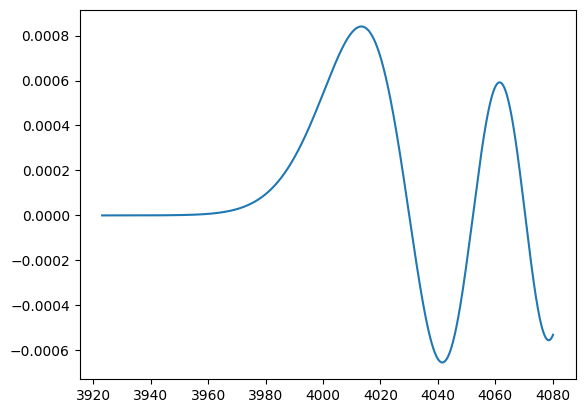

In [40]:
l=4000
func = spherical_jn
xs = jnp.linspace(first_x(l, func), first_x(l, func)+xmax, xsize)
plt.plot(xs, spherical_jn(l, xs))
#plt.xlim((4010, 4030))
plt.show()

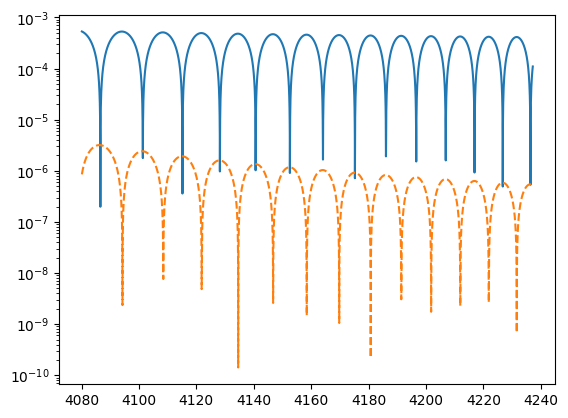

In [41]:
xs = jnp.linspace(first_x(l, func)+xmax, first_x(l, func)+2.*xmax, xsize)
plt.plot(xs, abs(spherical_jn(l, xs)))
plt.plot(xs, abs(spherical_jn(l, xs)-j(l, xs)), "--")
plt.yscale("log")
plt.show()

# Saving

## $\phi_0$

In [50]:
x_res = np.zeros((xsize, spectrum.bessel_l_tab.size))
jl_res = np.zeros((xsize, spectrum.bessel_l_tab.size))
func = spherical_jn
for i in range(spectrum.bessel_l_tab.size):
    l = spectrum.bessel_l_tab[i]
    if l <= 20:
        xs = jnp.linspace(0, xmax, xsize)
    else:
        xs = jnp.linspace(first_x(l, func), first_x(l, func)+xmax, xsize)
    x_res[:, i] = xs
    jl_res[:, i] = func(l, xs)

In [51]:
#np.savetxt(path+"/xphi0.txt", x_res)
#np.savetxt(path+"/phi0.txt", jl_res)

## $\phi_1$

2.070107977373211e-08


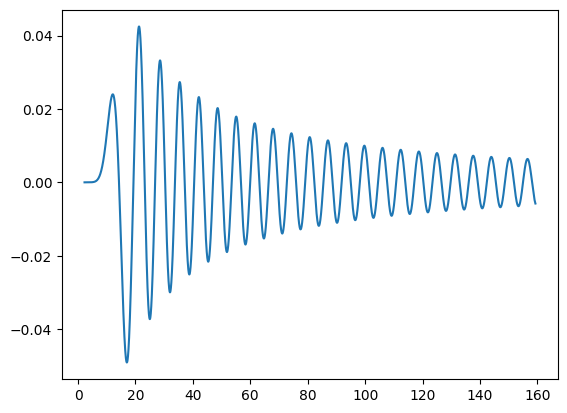

1.9108195041236324e-08


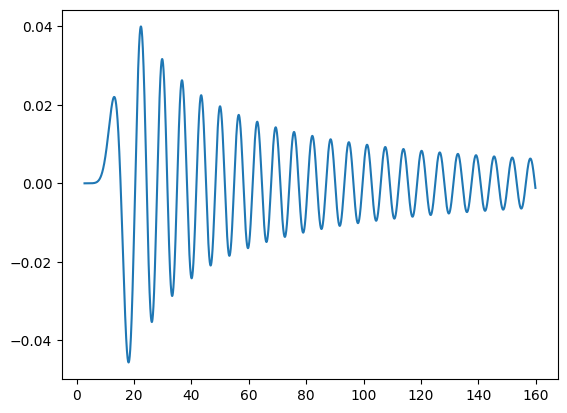

1.79589659425532e-08


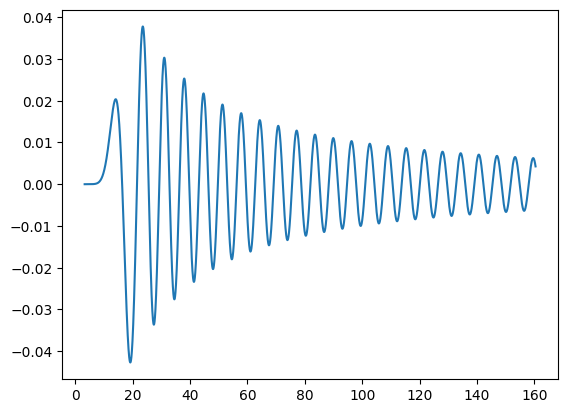

1.7094199684533145e-08


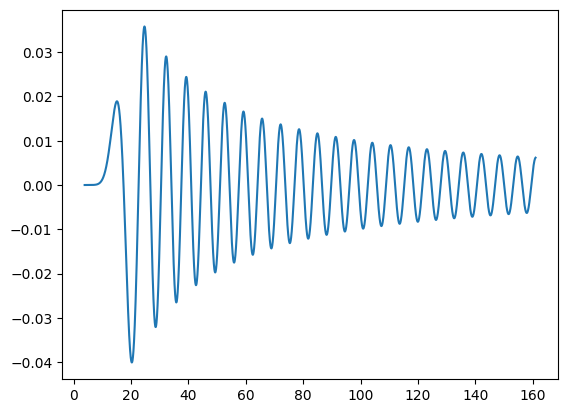

1.642150967358292e-08


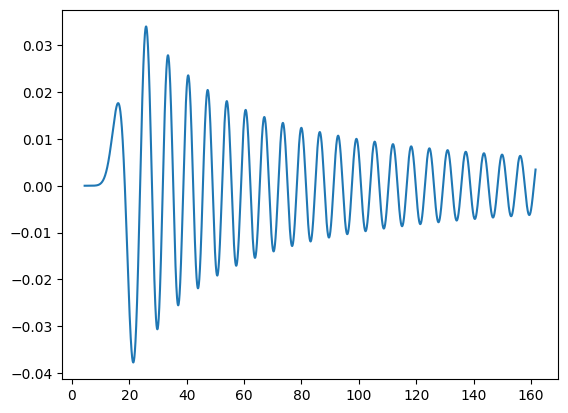

1.588401553274254e-08


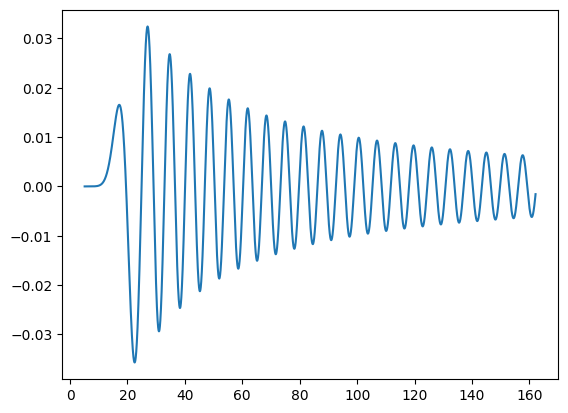

1.5079694639252713e-08


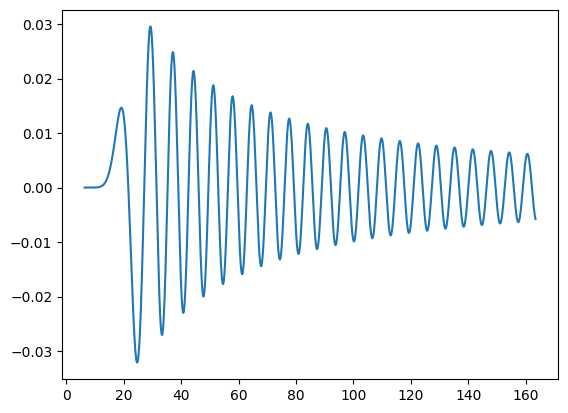

1.4506659461930446e-08


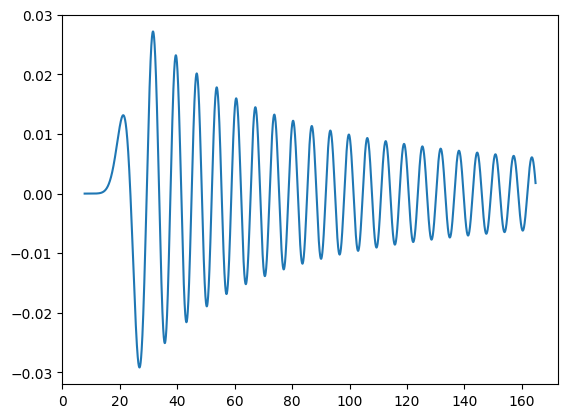

1.4077247406773385e-08


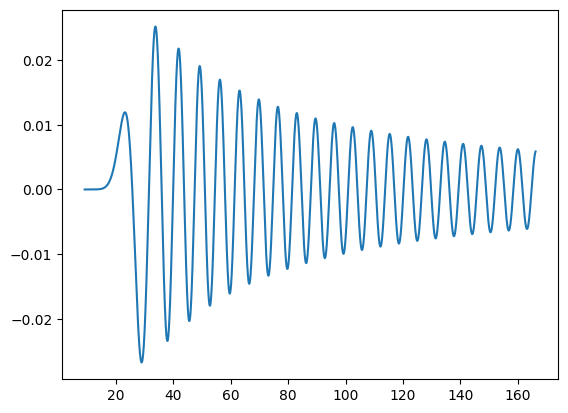

1.3742920253394023e-08


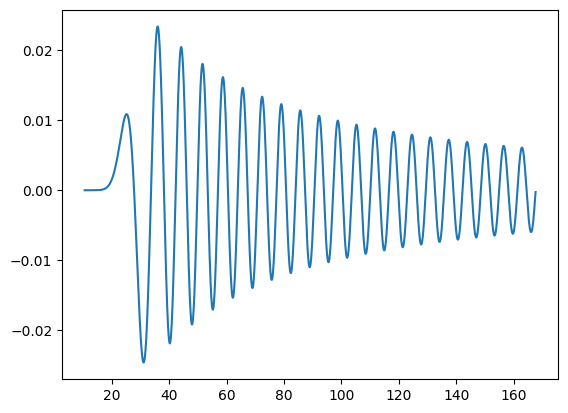

<Figure size 640x480 with 0 Axes>

In [23]:
x_res = np.zeros((xsize, spectrum.bessel_l_tab.size))
phi1_res = np.zeros((xsize, spectrum.bessel_l_tab.size))
func = lambda l, x : spherical_jn(l, x, derivative=True)
#for i in range(spectrum.bessel_l_tab.size):
for i in range(10, 20):
    l = spectrum.bessel_l_tab[i]
    xs = jnp.linspace(first_x(l, func), first_x(l, func)+xmax, xsize)
    print(func(l, xs[10]))
    plt.plot(xs, func(l, xs))
    plt.show()
    plt.clf()
    #phi1_res[:, i] = l/xs * spherical_jn(l, xs) - spherical_jn(l+1, xs)

## $\phi_2$

In [156]:
phi2_res = np.zeros((xsize, spectrum.bessel_l_tab.size))
for i in range(spectrum.bessel_l_tab.size):
    l = spectrum.bessel_l_tab[i]
    xs = jnp.linspace(first_x(l), first_x(l)+xmax, xsize)
    jlpp = 1/xs**2 * ((l**2-l-xs**2)*spherical_jn(l, xs) + 2*xs*spherical_jn(l+1, xs))
    phi2_res[:, i] = 1/2 * (3*jlpp + spherical_jn(l, xs))

In [151]:
#np.savetxt(path+"/phi2.txt", phi2_res)

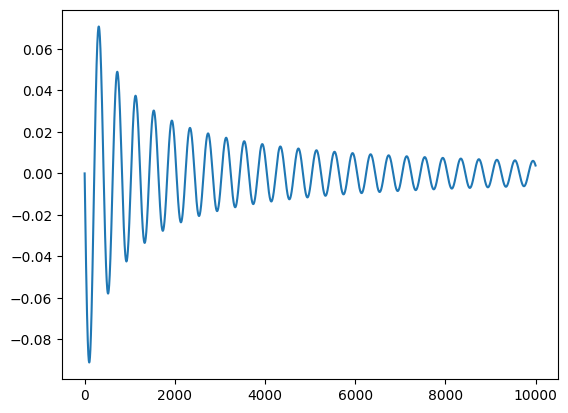

In [161]:
plt.plot(phi2_res[:, 0])
plt.show()